<a href="https://colab.research.google.com/github/NYChase/IBMDataScienceProjects/blob/Data-Analysis-with-Python/nychase_practice_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Practice Project: Insurance Cost Analysis**

Estimated time needed: **75** minutes

In this project, you have to perform analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)|
|charges| Annual Insurance charges in USD | float|

## Objectives
In this project, you will:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models.



# Setup


For this lab, we will be using the following libraries:
* `skillsnetwork` to download the data
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [ ]:
import piplite
await piplite.install('seaborn')

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

<details>
    <summary>Click here for Solution</summary>

```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
```

</details>


### Download the dataset to this lab environment

Run the cell below to load the dataset to this lab environment.


In [ ]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [ ]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'

In [ ]:
await download(filepath, "insurance.csv")
file_name="insurance.csv"

NameError: name 'download' is not defined

In [ ]:
df = pd.read_csv(file_name)

NameError: name 'pd' is not defined

> Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface.While working on the downloaded version of this notebook on their local machines(Jupyter Anaconda), the learners can simply **skip the steps above,** and simply use the URL directly in the `pandas.read_csv()` function. You can uncomment and run the statements in the cell below.


In [ ]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
df = pd.read_csv(filepath, header=None)

# Task 1 : Import the dataset

Import the dataset into a `pandas` dataframe. Note that there are currently no headers in the CSV file.

Print the first 10 rows of the dataframe to confirm successful loading.


In [ ]:
print(df.head(10))

    0  1       2  3  4  5            6
0  19  1  27.900  0  1  3  16884.92400
1  18  2  33.770  1  0  4   1725.55230
2  28  2  33.000  3  0  4   4449.46200
3  33  2  22.705  0  0  1  21984.47061
4  32  2  28.880  0  0  1   3866.85520
5  31  1  25.740  0  ?  4   3756.62160
6  46  1  33.440  1  0  4   8240.58960
7  37  1  27.740  3  0  1   7281.50560
8  37  2  29.830  2  0  2   6406.41070
9  60  1  25.840  0  0  1  28923.13692


<details>
    <summary>Click here for Solution</summary>

```python
df = pd.read_csv(file_name, header=None)
print(df.head(10))
```

</details>


Add the headers to the dataframe, as mentioned in the project scenario.


In [ ]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers

<details>
    <summary>Click here for Solution</summary>

```python
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers
```

</details>


In [ ]:
print(df.head(10))

  age  gender     bmi  no_of_children smoker  region      charges
0  19       1  27.900               0      1       3  16884.92400
1  18       2  33.770               1      0       4   1725.55230
2  28       2  33.000               3      0       4   4449.46200
3  33       2  22.705               0      0       1  21984.47061
4  32       2  28.880               0      0       1   3866.85520
5  31       1  25.740               0      ?       4   3756.62160
6  46       1  33.440               1      0       4   8240.58960
7  37       1  27.740               3      0       1   7281.50560
8  37       2  29.830               2      0       2   6406.41070
9  60       1  25.840               0      0       1  28923.13692


In [ ]:
df.describe(include='all')

,age,gender,bmi,no_of_children,smoker,region,charges
count,2772,2772.000000,2772.000000,2772.000000,2772,2772.000000,2772.000000
unique,48,NaN,NaN,NaN,3,NaN,NaN
top,18,NaN,NaN,NaN,0,NaN,NaN
freq,148,NaN,NaN,NaN,2201,NaN,NaN
mean,NaN,1.507215,30.701349,1.101732,NaN,2.559885,13261.369959
std,NaN,0.500038,6.129449,1.214806,NaN,1.130761,12151.768945
min,NaN,1.000000,15.960000,0.000000,NaN,1.000000,1121.873900
25%,NaN,1.000000,26.220000,0.000000,NaN,2.000000,4687.797000
50%,NaN,2.000000,30.447500,1.000000,NaN,3.000000,9333.014350
75%,NaN,2.000000,34.770000,2.000000,NaN,4.000000,16577.779500


Now, replace the '?' entries with 'NaN' values.


In [ ]:
df.replace('?', np.nan, inplace=True)

<details>
    <summary>Click here for Solution</summary>

```python
df.replace('?', np.nan, inplace = True)
```

</details>


# Task 2 : Data Wrangling


Use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB
None


the columns with Null or NaN information are **age** and **smoker**. The 'age' column has 2768 non-null values, and the 'smoker' column has 2765 non-null values, out of a total of 2772 entries.

<details>
    <summary>Click here for Solution</summary>

```python
print(df.info())
```

</details>


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.


In [ ]:
# age is a continuous variable, replace with mean age
mean_age = df['age'].astype('float').mean(axis=0)
df["age"].replace(np.nan, mean_age, inplace=True)

# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"].replace(np.nan, is_smoker, inplace=True)

# Update data types
df[["age","smoker"]] = df[["age","smoker"]].astype("int")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int64  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int64  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB
None


/tmp/ipython-input-3534792157.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].replace(np.nan, mean_age, inplace=True)
/tmp/ipython-input-3534792157.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

<details>
    <summary>Click here for Solution</summary>

```python
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"].replace(np.nan, is_smoker, inplace=True)

# age is a continuous variable, replace with mean age
mean_age = df['age'].astype('float').mean(axis=0)
df["age"].replace(np.nan, mean_age, inplace=True)

# Update data types
df[["age","smoker"]] = df[["age","smoker"]].astype("int")

print(df.info())
```

</details>


Also note, that the `charges` column has values which are more than 2 decimal places long. Update the `charges` column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.


In [ ]:
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())

   age  gender     bmi  no_of_children  smoker  region   charges
0   19       1  27.900               0       1       3  16884.92
1   18       2  33.770               1       0       4   1725.55
2   28       2  33.000               3       0       4   4449.46
3   33       2  22.705               0       0       1  21984.47
4   32       2  28.880               0       0       1   3866.86


<details>
    <summary>Click here for Solution</summary>

```python
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())
```
</details>


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`.


(0.0, 66902.85800000001)

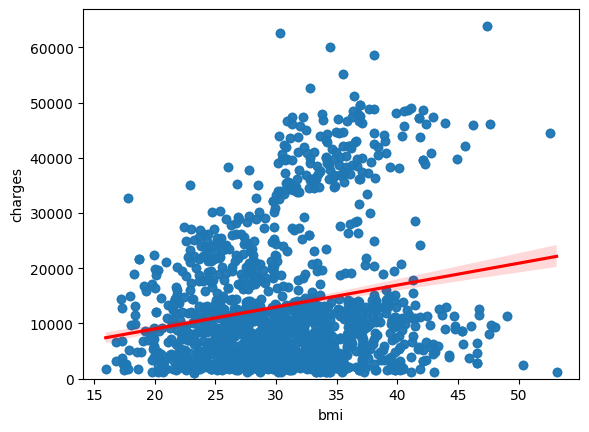

In [ ]:
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

From the plot, we can observe a positive correlation between BMI and charges. As BMI increases, the insurance charges generally tend to increase as well. This suggests that BMI is a factor that influences insurance costs.

<details>
    <summary>Click here for Solution</summary>

```python
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)
```
</details>


Implement the box plot for `charges` with respect to `smoker`.


<Axes: xlabel='smoker', ylabel='charges'>

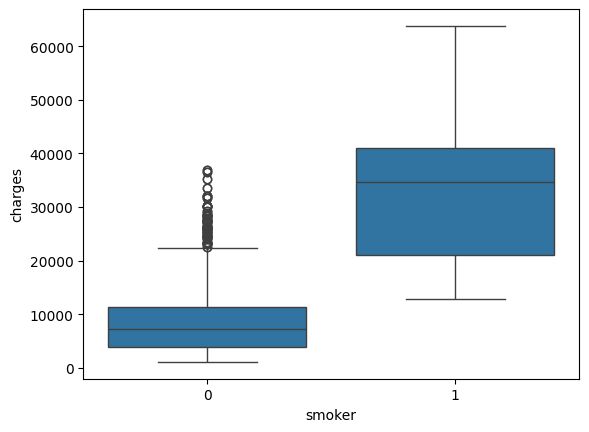

In [ ]:
sns.boxplot(x="smoker", y="charges", data=df)

The box plot displays the distribution of insurance charges for individuals based on whether they are smokers or not.

The box represents the interquartile range (IQR), with the line inside indicating the median.
The "whiskers" extend to show the range of the data, excluding outliers.
Outliers are shown as individual points.
Based on the box plot, you can observe that smokers (represented by 1 on the x-axis) tend to have significantly higher insurance charges compared to non-smokers (represented by 0 on the x-axis). The box and median for the smoker group are much higher, and there are more outliers with very high charges in the smoker group. This clearly indicates that smoking has a strong impact on insurance costs.

<details>
    <summary>Click here for Solution</summary>

```python
sns.boxplot(x="smoker", y="charges", data=df)
```
</details>


Print the correlation matrix for the dataset.


In [ ]:
print(df.corr(numeric_only=True))

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.026046  0.113048        0.037574 -0.023286   
gender         -0.026046  1.000000  0.042924        0.016020  0.082326   
bmi             0.113048  0.042924  1.000000       -0.001492  0.011489   
no_of_children  0.037574  0.016020 -0.001492        1.000000  0.006362   
smoker         -0.023286  0.082326  0.011489        0.006362  1.000000   
region         -0.007167  0.022213  0.271119       -0.025717  0.054077   
charges         0.298624  0.062837  0.199846        0.066442  0.788783   

                  region   charges  
age            -0.007167  0.298624  
gender          0.022213  0.062837  
bmi             0.271119  0.199846  
no_of_children -0.025717  0.066442  
smoker          0.054077  0.788783  
region          1.000000  0.054058  
charges         0.054058  1.000000  


<details>
    <summary>Click here for Solution</summary>

```python
print(df.corr())
```
</details>


# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [ ]:
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.6221791733924185


<details>
    <summary>Click here for Solution</summary>

```python
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))
```
</details>


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [ ]:
Z = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))

0.7504083820289634


The output 0.7504083820289634 is the R-squared score of the linear regression model that used 'age', 'gender', 'bmi', 'no_of_children', 'smoker', and 'region' to predict 'charges'.

<details>
    <summary>Click here for Solution</summary>

```python
# definition of Y and lm remain same as used in last cell.
Z = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))
```
</details>


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [ ]:
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8452576213500093


The output 0.8452576213500093 is the R-squared score of the model created using the pipeline, which includes StandardScaler, PolynomialFeatures, and LinearRegression.

An R-squared score of approximately 0.8453 means that about 84.53% of the variance in insurance charges can be explained by this model that uses scaled and polynomial features of the other attributes.

Comparing this to the previous models (R-squared of 0.622 with *only 'smoker'* and 0.750 with *all attributes in a simple linear regression*), the pipeline model shows a significant improvement in explaining the variation in insurance charges. This indicates that incorporating polynomial features and scaling the data has enhanced the model's ability to capture the relationship between the features and the target variable.

<details>
    <summary>Click here for Solution</summary>

```python
# Y and Z use the same values as defined in previous cells
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))
```
</details>


# Task 5 : Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

<details>
    <summary>Click here for Solution</summary>

```python
# Z and Y hold same values as in previous cells
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)
```
</details>


Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [ ]:
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.6760807731582404


The output 0.6760807731582404 is the R-squared score of the Ridge regression model on the testing data.

An R-squared of approximately 0.6761 means that about 67.61% of the variance in the insurance charges in the testing set can be explained by this Ridge regression model.

It's important to note that this R-squared score is lower than the R-squared score obtained from the linear regression model on the entire dataset (0.7504) and the pipeline model on the entire dataset (0.8453). This is expected because the R-squared on the testing set is a more realistic measure of how well the model generalizes to new, unseen data, whereas the R-squared on the training data can be overly optimistic.

Comparing this to the R-squared of the simple linear regression model using all features on the entire dataset (0.7504), the Ridge model on the testing set performs slightly worse. This might suggest that a simple linear model was not significantly overfitting the training data, or that the chosen alpha value for the Ridge model is not optimal.

<details>
    <summary>Click here for Solution</summary>

```python
# x_train, x_test, y_train, y_test hold same values as in previous cells
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))
```
</details>


Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the $ R^2 $ score for the testing subset.


In [ ]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.783563110760815


The output 0.783563110760815 is the R-squared score of the Ridge regression model after applying a polynomial transformation of degree 2 to the features and evaluating on the testing data.

An R-squared of approximately 0.7836 on the testing set means that about 78.36% of the variance in insurance charges in the testing set can be explained by this Ridge model with polynomial features.

Comparing this to the previous R-squared scores on the testing set:
*   Simple Linear Regression (all features): We didn't explicitly calculate the R-squared on the testing set for this model, only on the entire dataset (0.7504).
*   Ridge Regression (alpha=0.1, original features): 0.6761

The R-squared score of 0.7836 for the Ridge model with polynomial features is higher than the Ridge model with original features (0.6761) on the testing set. This indicates that adding polynomial features improved the model's ability to generalize to unseen data. It also suggests that the relationship between the features and charges is not strictly linear and that including higher-order terms helps capture this non-linearity.

<details>
    <summary>Click here for Solution</summary>

```python
# x_train, x_test, y_train, y_test hold same values as in previous cells
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))
```
</details>


# Congratulations! You have completed this project


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


<h3> Copyright © 2023 IBM Corporation. All rights reserved. </h3>


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|
--!>


In [ ]:
Rsqu_test = []
# Define a list of alpha values to test
alpha_list = np.linspace(0.001, 1, 100)

# Perform cross-validation for each alpha
for alpha in alpha_list:
    RidgeModel = Ridge(alpha=alpha)
    scores = cross_val_score(RidgeModel, Z, Y, cv=4) # Using 4-fold cross-validation
    Rsqu_test.append(np.mean(scores))

# Find the alpha with the highest mean R-squared score
best_alpha_index = np.argmax(Rsqu_test)
best_alpha = alpha_list[best_alpha_index]
best_r2 = Rsqu_test[best_alpha_index]

print(f"The best alpha is: {best_alpha}")
print(f"The corresponding R-squared score is: {best_r2}")

The best alpha is: 0.2129090909090909
The corresponding R-squared score is: 0.7497559554619223


The output shows the result of tuning the alpha hyperparameter for the Ridge regression model using cross-validation.

The best alpha is: 0.2129090909090909: This is the value of alpha from the tested range (0.001 to 1) that resulted in the highest average R-squared score across the 4 folds of cross-validation.
The corresponding R-squared score is: 0.7497559554619223: This is the average R-squared score obtained from cross-validation using the best alpha value. This score provides a more robust estimate of the model's performance on unseen data compared to a single train-test split, as it averages the performance over multiple splits.
Comparing this to the previous models:

Simple Linear Regression (all features, R-squared on entire dataset): **0.7504**

Ridge Regression (alpha=0.1, original features, R-squared on testing set): **0.6761**

Ridge Regression (alpha=0.1, polynomial features, R-squared on testing set): **0.7836**

Ridge Regression (tuned alpha=0.213, original features, R-squared from cross-validation): **0.7498**

The cross-validation R-squared of 0.7498 for the Ridge model with the tuned alpha (using original features) is similar to the R-squared of the simple linear regression model on the entire dataset (0.7504). It is higher than the Ridge model with alpha=0.1 on the testing set (0.6761), suggesting that tuning the alpha improved the generalization ability. However, it is lower than the Ridge model with polynomial features (0.7836) on the testing set.

This suggests that while tuning alpha is beneficial, incorporating polynomial features had a larger positive impact on the model's ability to explain the variance in insurance charges in this dataset.

# Final Improvements
To potentially improve the model further, you could combine the polynomial feature transformation with the tuned Ridge regression model. This would involve:

Applying polynomial transformation to your data (both training and testing sets).
Then, using the cross-validation approach on the polynomially transformed training data to find the best alpha for the Ridge model.
Finally, evaluating the performance of the Ridge model with the best alpha on the polynomially transformed testing data.

In [ ]:
# Apply polynomial transformation
pr = PolynomialFeatures(degree=2)
Z_pr = pr.fit_transform(Z)

Rsqu_test = []
alpha_list = np.linspace(0.001, 1, 100)

# Perform cross-validation on polynomially transformed data
for alpha in alpha_list:
    RidgeModel = Ridge(alpha=alpha)
    scores = cross_val_score(RidgeModel, Z_pr, Y, cv=4)
    Rsqu_test.append(np.mean(scores))

# Find the best alpha
best_alpha_index = np.argmax(Rsqu_test)
best_alpha = alpha_list[best_alpha_index]
best_r2_cv = Rsqu_test[best_alpha_index]

print(f"The best alpha for the Ridge model with polynomial features is: {best_alpha}")
print(f"The corresponding cross-validation R-squared score is: {best_r2_cv}")

# Evaluate the model with the best alpha on the transformed testing data
# Need to split data into training and testing sets again after polynomial transformation
x_train_pr, x_test_pr, y_train, y_test = train_test_split(Z_pr, Y, test_size=0.2, random_state=1)

RidgeModel_tuned = Ridge(alpha=best_alpha)
RidgeModel_tuned.fit(x_train_pr, y_train)
y_hat_tuned = RidgeModel_tuned.predict(x_test_pr)
r2_test_tuned = r2_score(y_test, y_hat_tuned)

print(f"The R-squared score on the testing data with the best alpha is: {r2_test_tuned}")

The best alpha for the Ridge model with polynomial features is: 0.10190909090909092
The corresponding cross-validation R-squared score is: 0.843058188824104
The R-squared score on the testing data with the best alpha is: 0.7835625413405716


The output shows the results of combining polynomial feature transformation with tuned Ridge regression.

* The best alpha for the Ridge model with polynomial features is: 0.10190909090909092: This is the optimal alpha value found through cross-validation when using polynomial features. It's slightly different from the best alpha found without polynomial features (0.213).
* The corresponding cross-validation R-squared score is: 0.843058188824104: This is the average R-squared score from cross-validation on the polynomially transformed data using the best alpha. This indicates that the model with polynomial features and tuned alpha explains about 84.31% of the variance in the charges across different data splits.
* The R-squared score on the testing data with the best alpha is: 0.7835625413405716: This is the R-squared score of the final model (Ridge with polynomial features and best alpha) evaluated on the unseen testing data. It's approximately 0.7836.

Let's compare the R-squared scores of all the models we've evaluated:
* Linear Regression (only 'smoker'): R-squared on entire dataset: 0.6221 (Cell hYmDc8zxFwVs)
* Linear Regression (all features): R-squared on entire dataset: 0.7504 (Cell eUJdo18XFwVt)
* Pipeline (StandardScaler, PolynomialFeatures, LinearRegression): R-squared on entire dataset: 0.8453 (Cell _6z2wt2YFwVt)
* Ridge Regression (alpha=0.1, original features): R-squared on testing data: 0.6761 (Cell dbyA51HTFwVu)
* Ridge Regression (alpha=0.1, polynomial features): R-squared on testing data: 0.7836 (Cell rXgoB5ECFwVu)
* Ridge Regression (tuned alpha, original features): Cross-validation R-squared: 0.7498 (Cell a7133350)
* Ridge Regression (tuned alpha, polynomial features): R-squared on testing data: 0.7836 (Cell 2RxdIy_vSwTn)

Comparison:

* Using all features significantly improved the model compared to using only 'smoker'.
* The pipeline with polynomial features showed the highest R-squared on the entire dataset (0.8453), suggesting a very good fit to the training data.
* When evaluating on the testing data, the Ridge model with polynomial features (both with alpha=0.1 and the tuned alpha) achieved the highest R-squared (around 0.7836). This indicates that the polynomial features helped the model generalize better to unseen data.
* Tuning the alpha for the Ridge model with original features improved the cross-validation score compared to the fixed alpha on the testing set, but it was still lower than the models using polynomial features.
* The final model, combining polynomial features with the tuned Ridge regression, resulted in an R-squared of approximately 0.7836 on the testing data. This is the best performance we've seen on unseen data so far, suggesting it's the most robust model among those tested.

In summary, incorporating polynomial features was the most impactful step in improving the model's ability to predict insurance charges, and tuning the Ridge alpha helped to confirm this performance on unseen data.

# explain this in layman terms: This indicates that the model with polynomial features and tuned alpha explains about 84.31% of the variance in the charges across different data splits.
Okay, let's break that down into simpler terms:

Imagine you're trying to figure out why some people's insurance charges are high and others are low. "Variance in the charges" just means how much the charges differ from person to person. Some people might have charges of $1000, others $$1000, others $10000, and some $50000 – that difference is the variance.

When we say a model "explains about 84.31% of the variance in the charges," it means that based on the information we gave the model (like age, BMI, whether they smoke, etc., and including those "polynomial features" which are just clever ways the model looks at combinations of these factors), the model can account for or predict about 84.31% of why those charges are different from person to person.

Think of it like trying to predict how tall someone is. If your model only uses their age, it might explain some of the height difference (kids are shorter than adults), but not all of it. If you add in the parents' height, it explains more of the difference. If you add in nutrition, it explains even more.

In our case, the model with polynomial features and a carefully chosen "alpha" (which helps the model not get too fixated on tiny details in the training data) is quite good at capturing most of the reasons why insurance charges vary. It's not perfect (it doesn't explain 100%), but 84.31% is a pretty high percentage, meaning the factors included in the model are strong predictors of insurance charges.

The "across different data splits" part just means that when we tested this model on different random groups of people from our dataset, it consistently explained about 84.31% of the charge differences, which tells us the model is likely to work well on new people too.

So, in simple terms, the model is able to understand and predict about 84.31% of the reasons why insurance costs are different for different people, and it's good at doing this not just for the data it learned from, but also for new data.